In [17]:
import numpy as np
import matplotlib.pyplot as plt
import astropy 
import astropy.units as u
from astropy.constants import M_sun
from astropy.constants import c
from astropy.constants import L_sun
import astropy.cosmology.units as cu
from astropy.cosmology import Planck18 as cosmo
from astropy.constants import L_sun
L_sun_eps = L_sun.cgs.value
plotsdir = "/beegfs/general/kprofit/binary_tests/al_td_96/plots"

In [18]:
#Load in the code units from the simulation snapshot.

import sys
#sys.path.insert(0, '/mnt/home/skoudmani/for_kasar/python_scripts/')
sys.path.insert(0, '/soft/python3/usr/local/lib64/python3.9/site-packages') #import default cluster packages
sys.path.insert(0, '/beegfs/general/skoudmani/students/kasar/python/') #import custom packages
import read_snap_files as rsf
snap_dir_orig = "/beegfs/general/kprofit/binary_tests/al_td_96/output_bhspin"
snap_name = rsf.get_snap_filename(snap_dir_orig, 100, snap_prefix="snapshot")
unitlength_in_cm = rsf.get_attribute(snap_name, "UnitLength_in_cm", param=True) #How much one 'code length unit' is in cm
unitmass_in_g = rsf.get_attribute(snap_name, "UnitMass_in_g", param=True)  #How much one 'code mass unit' is in grams
unitvelocity_in_cm_per_s = rsf.get_attribute(snap_name, "UnitVelocity_in_cm_per_s", param=True)  #How much one 'code velocity unit' is in cm per second
unittime_in_s = unitlength_in_cm / unitvelocity_in_cm_per_s   #How much one 'code time unit' is in seconds

print(unitlength_in_cm)
print(unitmass_in_g)
print(unitvelocity_in_cm_per_s)
print(unittime_in_s)

#Does unit mass refer to mass accretion or mass of BH?
#Unit length?
#Unit velocity?
#Unit time ~ 1 Myr

3.08568e+18
4.62681e+35
100000.0
30856800000000.0


In [19]:
#Constants Cell
c1 = [5.712,4.073] #c1 in soft and hard X-ray respectively
c2= [17.67,12.60] #c2 in soft and hard X-ray respectively
k1= [-0.026,0.278] #k1 in soft and hard X-ray respectively
k2= [0.278,0.278] #k2 in soft and hard X-ray respectively

c1_avg = [np.mean(c1)] #Mean c1 value between hard and soft x-ray
c2_avg = [np.mean(c2)] #Mean c2 value between hard and soft x-ray
k1_avg = [np.mean(k1)] #Mean k1 value between hard and soft x-ray
k2_avg = [np.mean(k2)] #Mean k2 value between hard and soft x-ray

(100,)


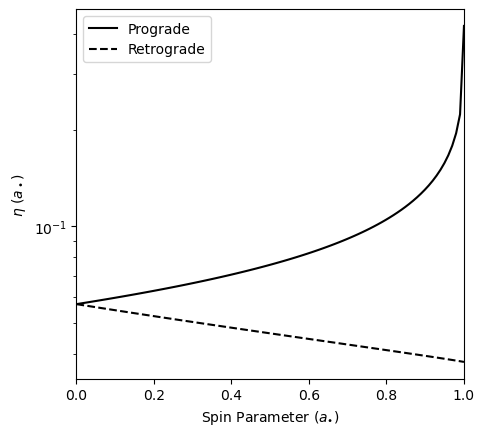

In [20]:
#Write code to recreate spin paramer plot from Fiacconi paper
#Use equations from paper to make plot
#All quantities are functions of spin a


a = np.linspace(0.0,1,100)
def z1(a):
    return 1 + (1 - a**2)**(1/3)*(1+a)**(1/3)+(1-a)**(1/3) #Function of spin a (Eq. B3 Fiacconi Paper)
def z2(a):
    return np.sqrt(3*a**2 + z1(a)**2) #Function of spin a (Eq. B4 Fiacconi Paper)
def Lam(a):
    Lam1 = 3 + z2(a) - np.sqrt((3-z1(a))*(3+z1(a)+2*z2(a))) #Lambda in prograde (Eq. B2 Fiacconi Paper)
    Lam2 = 3 + z2(a) + np.sqrt((3-z1(a))*(3+z1(a)+2*z2(a))) #Lambda in retrograde
    return Lam1,Lam2
def eta(a,corotating=True): 
    Lam1,Lam2 = Lam(a)
    eta1 = 1 - np.sqrt(1-(2/(3*Lam1)))
    eta2 = 1 - np.sqrt(1-(2/(3*Lam2))) #Radiative effeciency (Eq. B5 Fiacconi Paper)
    if corotating:
        return eta1 
    else:
        return eta2
#eta1,eta2 = eta(a)
eta1 = eta(a, corotating=True)
eta2 = eta(a, corotating=False)
#Plot Radiative efficiency as a function of spin vs. spin parameter
plt.figure().set_figwidth(5)
plt.plot(a,eta1,'k', label="Prograde")
plt.plot(a,eta2,'k--',label="Retrograde")
plt.yscale("log")
plt.xlabel("Spin Parameter ($a_{\\bullet})$")
plt.ylabel("$\eta \ (a_\\bullet$)")
plt.margins(x=0)
plt.legend(loc=2)

print(np.shape(eta1))

#plt.savefig("%s/Spin_Parameter.png" %plotsdir,bbox_inches='tight')
#plt.show()


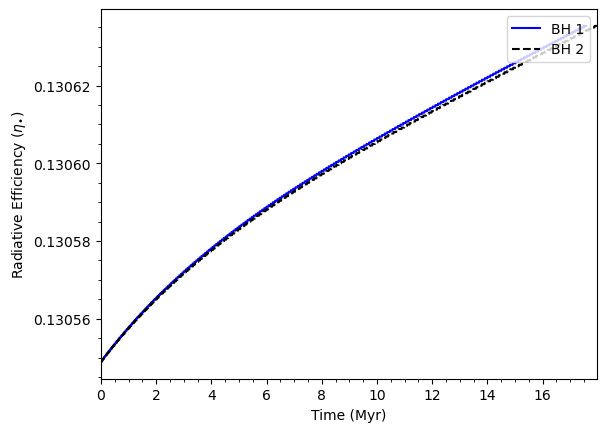

In [21]:
#Load in txt files for details on BH and BH spin

#run_dir = "/mnt/home/skoudmani/ceph/ADIOSProj/CIRCUMBINARY/NEW_SIM/q01e00i00/analysis/"
run_dir = "/beegfs/general/kprofit/binary_tests/al_td_96/output_bhspin/blackhole_details/"
details_file = "bh1_details.dat"
spin_file = "bh1_bhspin.dat"
details_file2 = "bh2_details.dat"
spin_file2 = "bh2_bhspin.dat"
spin_data = np.loadtxt(run_dir+spin_file)
bh_data = np.loadtxt(run_dir+details_file)
bh_data2 = np.loadtxt(run_dir+details_file2)
spin_data2 = np.loadtxt(run_dir+spin_file2)
time = spin_data[:,0] * 0.978462
spin = spin_data[:,3]
time2 = spin_data2[:,0]
spin2 = spin_data2[:,3]
efficiency = eta(spin, corotating=True)
efficiency2 = eta(spin2, corotating=True)
#print(spin)
#print(bh_data)
#print(time2)
#print(time)
#print(efficiency)

#Plot radiative efficiency vs time

plt.plot(time, efficiency, 'b', label='BH 1')
plt.plot(time2, efficiency,'k--', label="BH 2")
plt.ylabel("Radiative Efficiency ($\eta_{\\bullet}) $")
plt.xlabel("Time (Myr)")
plt.style.context('bmh')
plt.minorticks_on()
plt.legend(loc=1)
plt.margins(x=0)

#plt.savefig("%s/Radiative_Efficiency.png" %plotsdir,bbox_inches='tight')

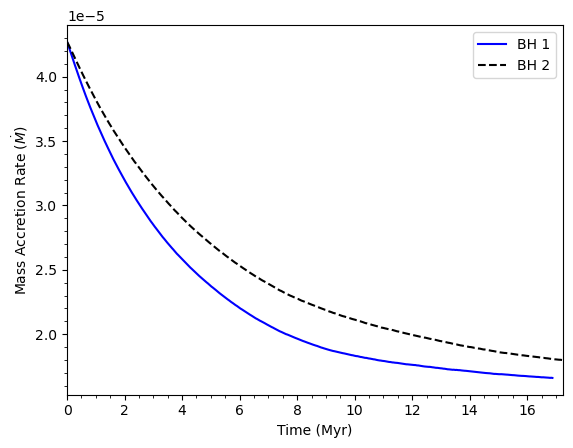

In [24]:
#Convert M_dot units 
from astropy.constants import M_sun

mdot = bh_data[:,2][:9001] #mass accretion rate of BH1
mdot2 = bh_data2[:,2][:9001] #mass accretion rate of BH2
mdot_Msunyr = mdot * (unitmass_in_g / M_sun.cgs.value) / (unittime_in_s / (365*24*3600)) #to convert to Msun yr-1
mdot_cgs = mdot * (unitmass_in_g) / (unittime_in_s)
mdot_cgs2 = mdot2 * (unitmass_in_g) / (unittime_in_s)#to convert to cgs units
mdot_Msunyr2 = mdot2 * (unitmass_in_g / M_sun.cgs.value) / (unittime_in_s / (365*24*3600)) #to convert to Msun yr-1

time = spin_data[:,0][:9001] * 0.978462
time2 = spin_data2[:,0][:9001]

#Mdot vs time 

plt.plot(time, mdot_Msunyr, 'b', label='BH 1')
plt.plot(time2,mdot_Msunyr2, 'k--', label='BH 2')
plt.ylabel("Mass Accretion Rate ($\dot{M})$")
plt.xlabel("Time (Myr)") #1 code unit ~ 1 Myr
plt.style.context('bmh')
plt.minorticks_on()
plt.legend(loc=1)
plt.margins(x=0)

#plt.savefig("%s/Mass_Acc_Rate.png" %plotsdir,bbox_inches='tight')

In [30]:
#Compare length of details and spin files
print(np.shape(mdot_cgs))
print(np.shape(mdot_cgs2))

(9001,)
(9001,)


(9001,)
(9001,)
(9001,)
(9001,)
[2.69201507e+21 2.69116039e+21 2.69029071e+21 ... 1.04682911e+21
 1.04677363e+21 1.04674364e+21]


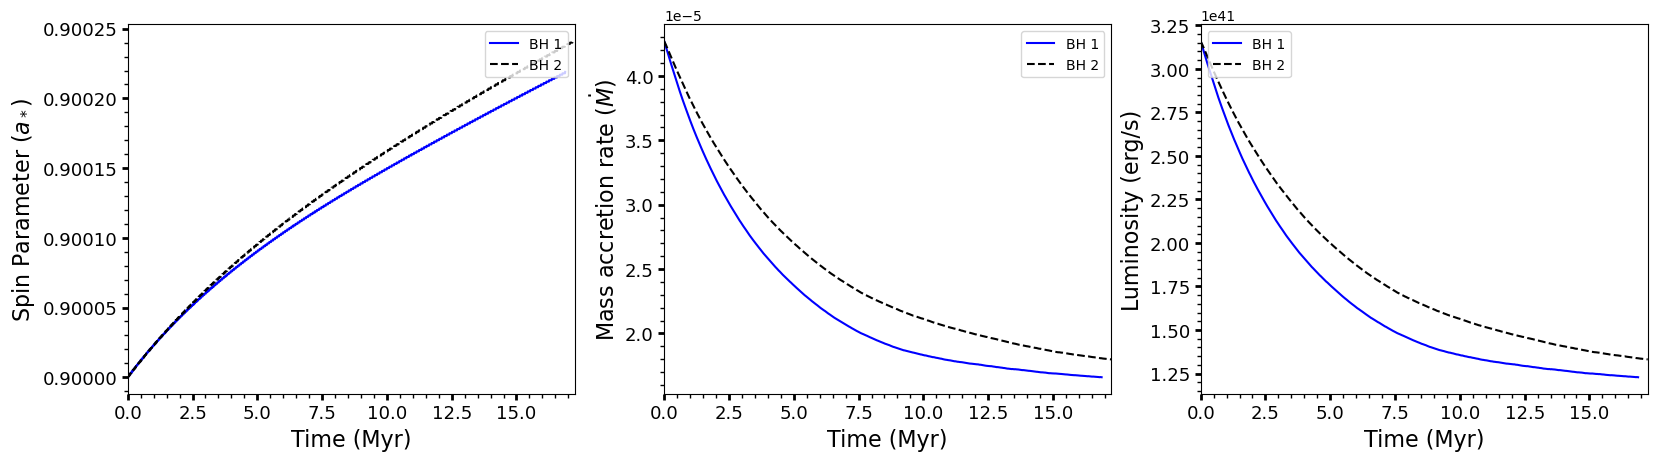

In [31]:
#Subplots of Valuable quantites vs. time 
#Calculate Luminosity
def calculate_luminosities(a,mdot_cgs): 
    c_light_cgs = c.cgs.value 
    rad_eff = eta(a)
    print(np.shape(rad_eff))
    print(np.shape(mdot_cgs))
    L = rad_eff * mdot_cgs * c_light_cgs**2
    return L
    
 #calculate x-ray luminsoities

spin = spin_data[:,3][:9001]
spin2 = spin_data2[:,3][:9001]

luminosities = calculate_luminosities(spin ,mdot_cgs)
luminosities2 = calculate_luminosities(spin2 ,mdot_cgs2)
print(mdot_cgs)

f, (ax1, ax2, ax3) = plt.subplots(1,3)
ax1.plot(time,spin, 'b', label='BH 1')
ax1.plot(time2,spin2,'k--',label='BH 2')
#ax1.set_title('Time vs. $\eta_{\\bullet} $',fontsize=16)
ax1.set_xlabel('Time (Myr)',fontsize=16)
ax1.set_ylabel('Spin Parameter $(a_*$)',fontsize=16)
ax1.tick_params(direction='out',which = 'major', length=4, width=2, labelsize=13)
ax1.tick_params(direction='out',which = 'minor', length=3, width=1)
ax1.minorticks_on()
ax1.legend(loc=1)
ax1.margins(x=0)

ax2.plot(time, mdot_Msunyr, 'b', label='BH 1')
ax2.plot(time2,mdot_Msunyr2,'k--',label='BH 2')
#ax2.set_title('Time vs. $M_{\\bullet}$',fontsize=16)
ax2.set_xlabel('Time (Myr)',fontsize=16)
ax2.set_ylabel('Mass accretion rate ($\dot{M})$',fontsize=16)
ax2.tick_params(direction='out',which = 'major', length=4, width=2, labelsize=13)
ax2.tick_params(direction='out',which = 'minor', length=3, width=1)
ax2.minorticks_on()
ax2.legend(loc=1)
ax2.margins(x=0)

ax3.plot(time,luminosities, 'b', label='BH 1')
ax3.plot(time2,luminosities2, 'k--', label='BH 2')
#ax3.set_title('Time vs. Luminosity ($a_{\\bullet})$',fontsize=16)
ax3.set_xlabel('Time (Myr)',fontsize=16)
ax3.set_ylabel("Luminosity (erg/s)",fontsize=16)
ax3.tick_params(direction='out',which = 'major', length=4, width=2, labelsize=13)
ax3.tick_params(direction='out',which = 'minor', length=3, width=1)
ax3.minorticks_on()
ax3.margins(x=0)
ax3.legend(loc=2)
plt.subplots_adjust(right=2.5)
plt.style.context('bmh')

plt.savefig("%s/Combined_Plots.png" %plotsdir,bbox_inches='tight')

(50000,)
(50000,)
(50000,)
(50000,)


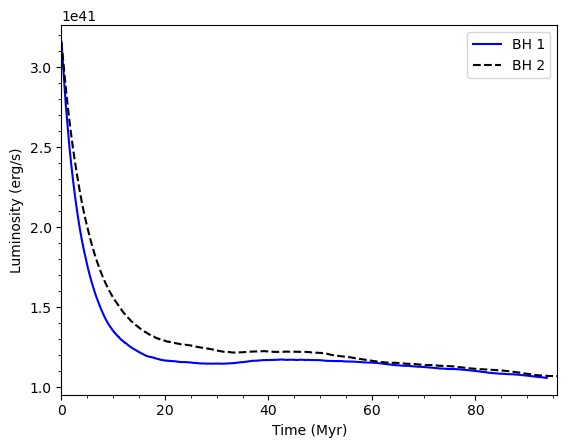

In [20]:
### Convert M_sun per year to ergs per second
from astropy import units as u
from astropy.constants import c

#M_sunyr = u.solMass / u.a
#M_sungs = u.g / u.s
#eps =  u.erg / u.s
#M_sunyr.to(M_sungs) 


#Define function for luminsity

def calculate_luminosities(a,mdot_cgs):
    rad_eff = eta(a)
    print(np.shape(rad_eff))
    print(np.shape(mdot_cgs))
    L = rad_eff * mdot_cgs * c_light_cgs**2
    return L

c_light_cgs = c.cgs.value 
luminosities = calculate_luminosities(spin ,mdot_cgs)
luminosities2 = calculate_luminosities(spin2 ,mdot_cgs2)

#Plot Luminosity vs. time

plt.plot(time,luminosities, 'b', label='BH 1')
plt.plot(time2,luminosities2, 'k--', label='BH 2')
plt.ylabel("Luminosity (erg/s)")
plt.xlabel("Time (Myr)")
plt.minorticks_on()
plt.style.context('bmh')
plt.legend(loc=1)
plt.margins(x=0)

#plt.savefig("%s/Luminosity.png" %plotsdir,bbox_inches='tight')

In [21]:
#Check length of variables
print(np.shape(time))
print(np.shape(mdot_cgs))

import inspect
print(inspect.getsource(calculate_luminosities))


(50000,)
(50000,)
def calculate_luminosities(a,mdot_cgs):
    rad_eff = eta(a)
    print(np.shape(rad_eff))
    print(np.shape(mdot_cgs))
    L = rad_eff * mdot_cgs * c_light_cgs**2
    return L



3.828e+33


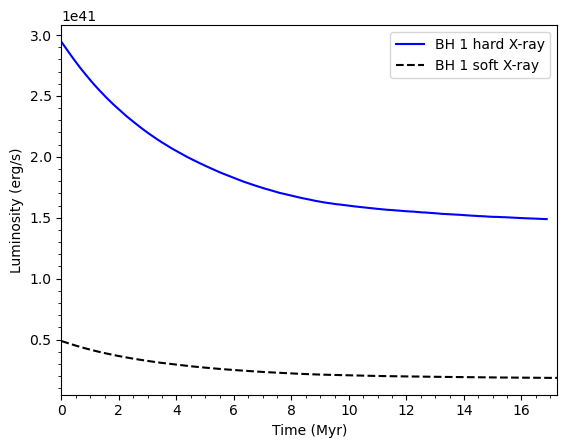

In [32]:
#Convert L_sun to ergs/s
from astropy.constants import L_sun
L_sun_eps = L_sun.cgs.value
print(L_sun_eps)

#Define function for luminosity in X-ray portion of EM spectrum
c1 = [5.712,4.073] #c1 in soft and hard X-ray respectively
c2= [17.67,12.60] #c2 in soft and hard X-ray respectively
k1= [-0.026,0.278] #k1 in soft and hard X-ray respectively
k2= [0.278,0.278] #k2 in soft and hard X-ray respectively

def calculate_L_band(calculate_luminosities):
    Lum_xray_h = (bol_lum_1) / ((c1[1](bol_lum_1/(10**10)*L_sun_eps)**k1[1])) + ((c2[1](bol_lum_1/(10**10)*L_sun_eps))**k2[1]) #Luminosity in hard x-ray for BH1
    Lum_xray_s2 = (bol_lum_2) / ((c1[0](bol_lum_2/(10**10)*L_sun_eps)**k1[0])) + ((c2[0](bol_lum_2/(10**10)*L_sun_eps))**k2[0]) #Luminosity in soft x-ray for BH2
    Lum_xray_h2 = (bol_lum_2) / ((c1[1](bol_lum_2/(10**10)*L_sun_eps)**k1[1])) + ((c2[1](bol_lum_2/(10**10)*L_sun_eps))**k2[1]) #Luminosity in hard x-ray for BH2
    return Lum_xray_s,Lum_xray_h,Lum_xray_s2,Lum_xray_s2

def get_bol_correction(bol_lum,c1,c2,k1,k2):
    Lum_band = (bol_lum) / ((c1*(bol_lum/((10**10)*L_sun_eps))**k1)) + ((c2*(bol_lum/((10**10)*L_sun_eps))**k2))
    return Lum_band

xray_h1 = get_bol_correction(luminosities,c1[1],c2[1],k1[1],k2[1])
xray_s1 = get_bol_correction(luminosities,c1[0],c2[0],k1[0],k2[0])
#Plot hard and soft X-ray luminosities
                                           
#plt.plot(time, , 'b', label='BH 1 soft X-ray')
plt.plot(time,xray_h1, 'b', label='BH 1 hard X-ray')
plt.plot(time2,xray_s1, 'k--', label='BH 1 soft X-ray')
#plt.plot(time2,L_band_h2, 'k--', label='BH 2 hard X-ray')                
plt.ylabel("Luminosity (erg/s)")
plt.xlabel("Time (Myr)")
plt.minorticks_on()
plt.style.context('bmh')
plt.legend(loc=1)
plt.margins(x=0)

                                         